# IPL Win-Insight Explorer 🏏

**Live-commentary style EDA on every IPL ball ever bowled.**

This notebook answers the kind of questions you hear on TV:
- *"If a team scores 60+ in the powerplay, what are their win chances?"*
- *"What happens to the chasing team's win probability if they lose 2 wickets in the powerplay?"*
- *"Which venues are batting paradises vs bowler-friendly?"*
- *"Does winning the toss really matter?"*

**Prerequisite:** run `get_ipl_data.py` first so `deliveries_features.csv` and `matches.csv` exist.

## 1. Setup & Load Data

In [14]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# CHANGE THIS PATH if your CSVs live elsewhere
DATA_DIR = '.'

deliveries = pd.read_csv(f'{DATA_DIR}/deliveries_features.csv')
matches    = pd.read_csv(f'{DATA_DIR}/matches.csv')

print('Deliveries:', deliveries.shape)
print('Matches:   ', matches.shape)
deliveries.head(3)

Deliveries: (291328, 48)
Matches:    (1225, 16)


/var/folders/gx/3gdq96p95zjccbgmh9jprnx40000gn/T/ipykernel_85889/2406529693.py:13: DtypeWarning:

Columns (1,42) have mixed types. Specify dtype option on import or set low_memory=False.



,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,is_wide,is_noball,is_bye,is_legbye,is_wicket,total_runs,is_four,is_six,is_legal_delivery,ball_outcome,current_score,current_wickets,over_num,ball_in_over,legal_balls_bowled,balls_remaining,current_run_rate,runs_last_30_balls,wickets_last_30_balls,phase,season_m,venue_m,city,toss_winner,toss_decision,winner
0,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,0.1,Sunrisers Hyderabad,Royal Challengers Bengaluru,DA Warner,S Dhawan,TS Mills,0,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,1,0 runs,0,0,0,1,1,119,0.0,0.0,0.0,powerplay,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Royal Challengers Bengaluru,field,Sunrisers Hyderabad
1,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,0.2,Sunrisers Hyderabad,Royal Challengers Bengaluru,DA Warner,S Dhawan,TS Mills,0,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,1,0 runs,0,0,0,2,2,118,0.0,0.0,0.0,powerplay,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Royal Challengers Bengaluru,field,Sunrisers Hyderabad
2,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,0.3,Sunrisers Hyderabad,Royal Challengers Bengaluru,DA Warner,S Dhawan,TS Mills,4,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0,0,0,0,0,4,1,0,1,FOUR,4,0,0,3,3,117,8.0,4.0,0.0,powerplay,2017,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Royal Challengers Bengaluru,field,Sunrisers Hyderabad


In [15]:
# Quick sanity check - what columns we have to play with
print('Columns:')
print(deliveries.columns.tolist())
print('\nSeasons covered:', sorted(deliveries['season'].dropna().unique().tolist()))

Columns:
['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed', 'is_wide', 'is_noball', 'is_bye', 'is_legbye', 'is_wicket', 'total_runs', 'is_four', 'is_six', 'is_legal_delivery', 'ball_outcome', 'current_score', 'current_wickets', 'over_num', 'ball_in_over', 'legal_balls_bowled', 'balls_remaining', 'current_run_rate', 'runs_last_30_balls', 'wickets_last_30_balls', 'phase', 'season_m', 'venue_m', 'city', 'toss_winner', 'toss_decision', 'winner']


TypeError: '<' not supported between instances of 'str' and 'int'

## 2. Phase-level Summaries

We need per-innings stats by phase (powerplay / middle / death). This is the foundation for almost every insight below.

**Phases**
- Powerplay: overs 0-5 (first 6 overs)
- Middle: overs 6-14
- Death: overs 15-19

In [16]:
# Build innings x phase summary: runs scored, wickets lost
phase_summary = (
    deliveries
    .groupby(['match_id', 'innings', 'batting_team', 'bowling_team', 'phase'], observed=True)
    .agg(runs=('total_runs', 'sum'),
         wickets=('is_wicket', 'sum'),
         balls=('is_legal_delivery', 'sum'))
    .reset_index()
)

# Flatten to one row per innings (wide format)
phase_wide = phase_summary.pivot_table(
    index=['match_id', 'innings', 'batting_team', 'bowling_team'],
    columns='phase',
    values=['runs', 'wickets'],
    fill_value=0
).reset_index()

# Flatten the multi-index columns
phase_wide.columns = ['_'.join([str(c) for c in col]).strip('_') for col in phase_wide.columns]

# Merge winner from matches
phase_wide = phase_wide.merge(
    matches[['match_id', 'winner', 'season', 'venue']],
    on='match_id', how='left'
)
phase_wide['match_id'] = phase_wide['match_id'].astype(str)
matches['match_id']    = matches['match_id'].astype(str)

# Did THIS innings's batting team win the match?
phase_wide['batting_team_won'] = (phase_wide['batting_team'] == phase_wide['winner']).astype(int)

print('Innings rows:', len(phase_wide))
phase_wide.head()

Innings rows: 2478


,match_id,innings,batting_team,bowling_team,runs_death,runs_middle,runs_powerplay,wickets_death,wickets_middle,wickets_powerplay,winner,season,venue,batting_team_won
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,68.0,93.0,61.0,1.0,1.0,1.0,Kolkata Knight Riders,2007/08,M Chinnaswamy Stadium,1
1,335982,2,Royal Challengers Bengaluru,Kolkata Knight Riders,1.0,55.0,26.0,1.0,5.0,4.0,Kolkata Knight Riders,2007/08,M Chinnaswamy Stadium,0
2,335983,1,Chennai Super Kings,Punjab Kings,79.0,108.0,53.0,1.0,3.0,1.0,Chennai Super Kings,2007/08,"Punjab Cricket Association Stadium, Mohali",1
3,335983,2,Punjab Kings,Chennai Super Kings,42.0,102.0,63.0,1.0,2.0,1.0,Chennai Super Kings,2007/08,"Punjab Cricket Association Stadium, Mohali",0
4,335984,1,Rajasthan Royals,Delhi Capitals,33.0,56.0,40.0,1.0,5.0,2.0,Delhi Capitals,2007/08,Feroz Shah Kotla,0


## 3. 🔥 Powerplay Insight: How important is a fast start?

**Question:** *Does a strong powerplay actually translate to winning the match?*

In [17]:
# Bin powerplay runs into buckets and compute win rate
pp = phase_wide.copy()
pp['pp_runs_bucket'] = pd.cut(
    pp['runs_powerplay'],
    bins=[-1, 30, 40, 50, 60, 70, 200],
    labels=['<30', '30-39', '40-49', '50-59', '60-69', '70+']
)

pp_win_rate = (
    pp.groupby('pp_runs_bucket', observed=True)
    .agg(matches=('match_id', 'count'),
         wins=('batting_team_won', 'sum'))
    .reset_index()
)
pp_win_rate['win_rate_%'] = (pp_win_rate['wins'] / pp_win_rate['matches'] * 100).round(1)
pp_win_rate

,pp_runs_bucket,matches,wins,win_rate_%
0,<30,228,55,24.1
1,30-39,509,201,39.5
2,40-49,748,354,47.3
3,50-59,588,317,53.9
4,60-69,265,170,64.2
5,70+,140,103,73.6


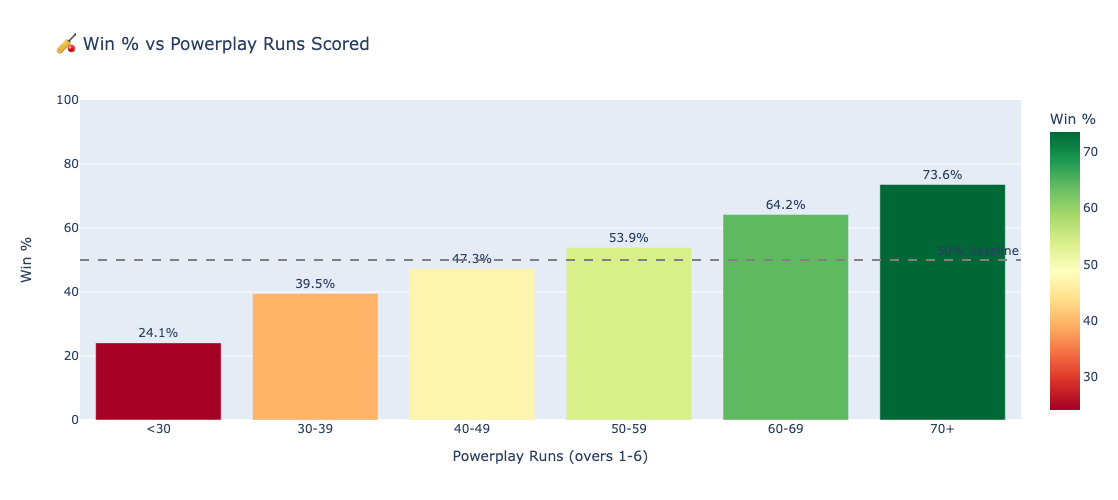

In [18]:
fig = px.bar(
    pp_win_rate,
    x='pp_runs_bucket', y='win_rate_%',
    text='win_rate_%',
    color='win_rate_%',
    color_continuous_scale='RdYlGn',
    hover_data={'matches': True, 'wins': True},
    title='🏏 Win % vs Powerplay Runs Scored',
    labels={'pp_runs_bucket': 'Powerplay Runs (overs 1-6)', 'win_rate_%': 'Win %'}
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(height=500, showlegend=False, yaxis_range=[0, 100])
fig.add_hline(y=50, line_dash='dash', line_color='grey',
              annotation_text='50% baseline', annotation_position='top right')
fig.show()

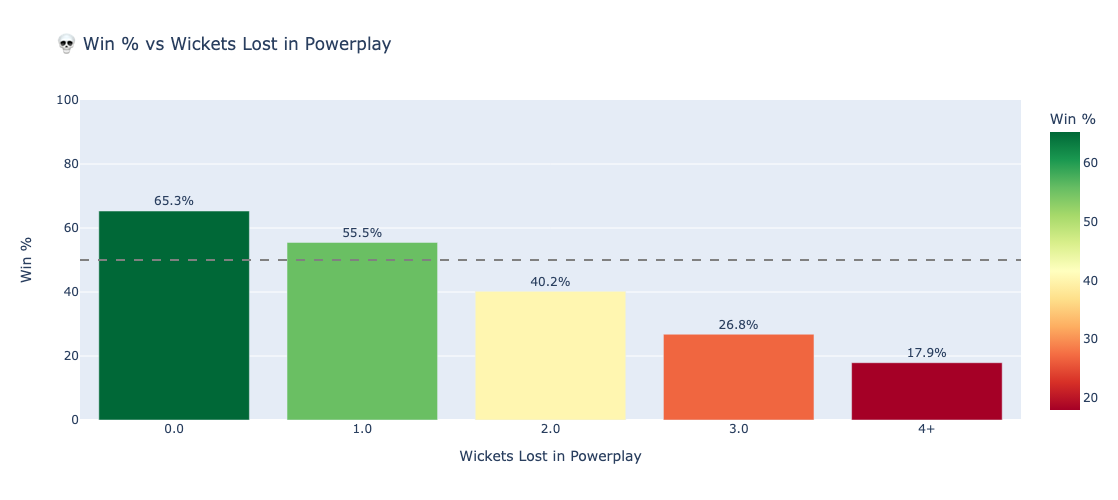

In [19]:
# Wickets lost in powerplay -> win rate
pp['pp_wkts_bucket'] = pp['wickets_powerplay'].clip(upper=4)  # 4+ together

pp_w_win = (
    pp.groupby('pp_wkts_bucket')
    .agg(matches=('match_id', 'count'),
         wins=('batting_team_won', 'sum'))
    .reset_index()
)
pp_w_win['win_rate_%'] = (pp_w_win['wins'] / pp_w_win['matches'] * 100).round(1)
pp_w_win['pp_wkts_label'] = pp_w_win['pp_wkts_bucket'].astype(str)
pp_w_win.loc[pp_w_win['pp_wkts_bucket'] == 4, 'pp_wkts_label'] = '4+'

fig = px.bar(
    pp_w_win,
    x='pp_wkts_label', y='win_rate_%',
    text='win_rate_%',
    color='win_rate_%',
    color_continuous_scale='RdYlGn',
    hover_data={'matches': True, 'wins': True},
    title='💀 Win % vs Wickets Lost in Powerplay',
    labels={'pp_wkts_label': 'Wickets Lost in Powerplay', 'win_rate_%': 'Win %'}
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(height=500, showlegend=False, yaxis_range=[0, 100])
fig.add_hline(y=50, line_dash='dash', line_color='grey')
fig.show()

## 4. 🎯 The Killer Combo: Runs AND Wickets in Powerplay

*What if a team is 60+ for 0 vs 60+ for 3 after the powerplay? Big difference.*

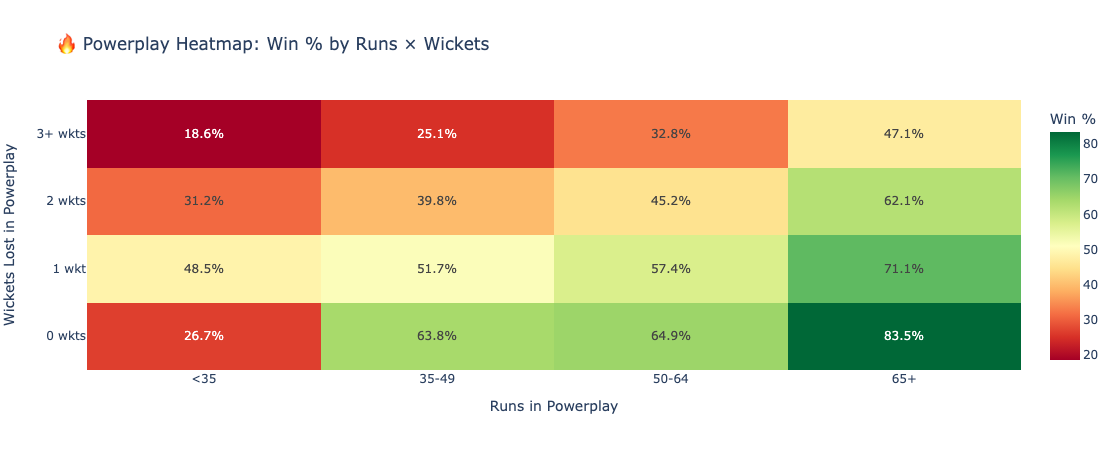

In [20]:
pp['pp_runs_b'] = pd.cut(pp['runs_powerplay'],
                          bins=[-1, 35, 50, 65, 200],
                          labels=['<35', '35-49', '50-64', '65+'])
pp['pp_wkts_b'] = pp['wickets_powerplay'].clip(upper=3).astype(int)

heat = (pp.groupby(['pp_runs_b', 'pp_wkts_b'], observed=True)
          .agg(matches=('match_id', 'count'),
               wins=('batting_team_won', 'sum'))
          .reset_index())
heat['win_rate'] = (heat['wins'] / heat['matches'] * 100).round(1)

heat_pivot      = heat.pivot(index='pp_wkts_b', columns='pp_runs_b', values='win_rate')
matches_pivot   = heat.pivot(index='pp_wkts_b', columns='pp_runs_b', values='matches')

# Custom hover text with sample size
hover_text = []
for i in heat_pivot.index:
    row = []
    for j in heat_pivot.columns:
        wr = heat_pivot.loc[i, j]
        n  = matches_pivot.loc[i, j]
        row.append(f'Win Rate: {wr}%<br>Sample: {int(n) if pd.notna(n) else 0} innings')
    hover_text.append(row)

fig = go.Figure(data=go.Heatmap(
    z=heat_pivot.values,
    x=[str(c) for c in heat_pivot.columns],
    y=['0 wkts', '1 wkt', '2 wkts', '3+ wkts'],
    colorscale='RdYlGn',
    text=heat_pivot.values,
    texttemplate='%{text}%',
    hoverinfo='text',
    hovertext=hover_text,
    colorbar=dict(title='Win %')
))
fig.update_layout(
    title='🔥 Powerplay Heatmap: Win % by Runs × Wickets',
    xaxis_title='Runs in Powerplay',
    yaxis_title='Wickets Lost in Powerplay',
    height=450
)
fig.show()

## 5. 💀 Death Overs Magic

*"Death overs win matches" — let's actually check.*

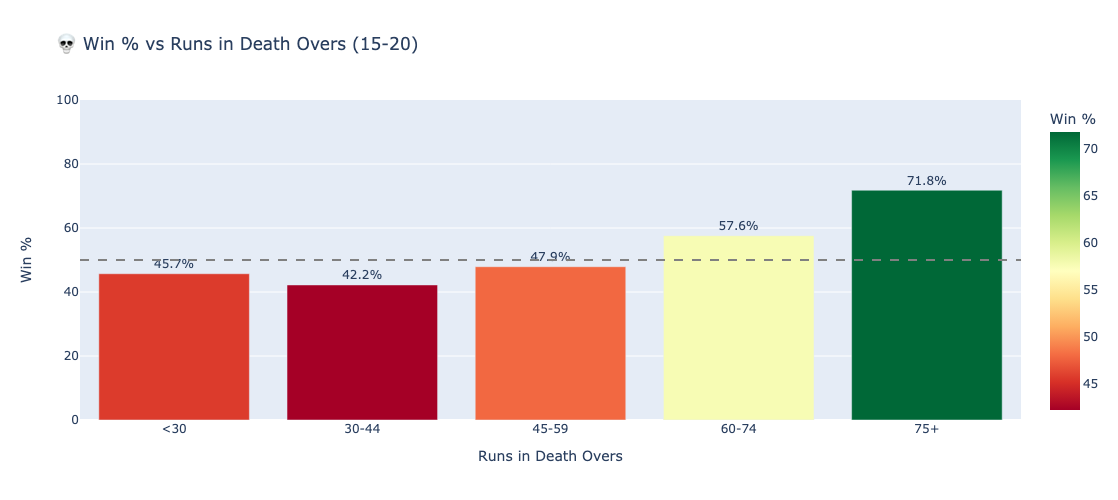

In [21]:
death = phase_wide[phase_wide['runs_death'] > 0].copy()
death['death_runs_bucket'] = pd.cut(
    death['runs_death'],
    bins=[-1, 30, 45, 60, 75, 200],
    labels=['<30', '30-44', '45-59', '60-74', '75+']
)

d_win = (death.groupby('death_runs_bucket', observed=True)
         .agg(matches=('match_id', 'count'),
              wins=('batting_team_won', 'sum'))
         .reset_index())
d_win['win_rate_%'] = (d_win['wins'] / d_win['matches'] * 100).round(1)

fig = px.bar(
    d_win,
    x='death_runs_bucket', y='win_rate_%',
    text='win_rate_%',
    color='win_rate_%',
    color_continuous_scale='RdYlGn',
    hover_data={'matches': True, 'wins': True},
    title='💀 Win % vs Runs in Death Overs (15-20)',
    labels={'death_runs_bucket': 'Runs in Death Overs', 'win_rate_%': 'Win %'}
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(height=500, yaxis_range=[0, 100], showlegend=False)
fig.add_hline(y=50, line_dash='dash', line_color='grey')
fig.show()

## 6. 🏆 Per-Team Powerplay Performance

*Which teams convert powerplay dominance into wins most efficiently?*

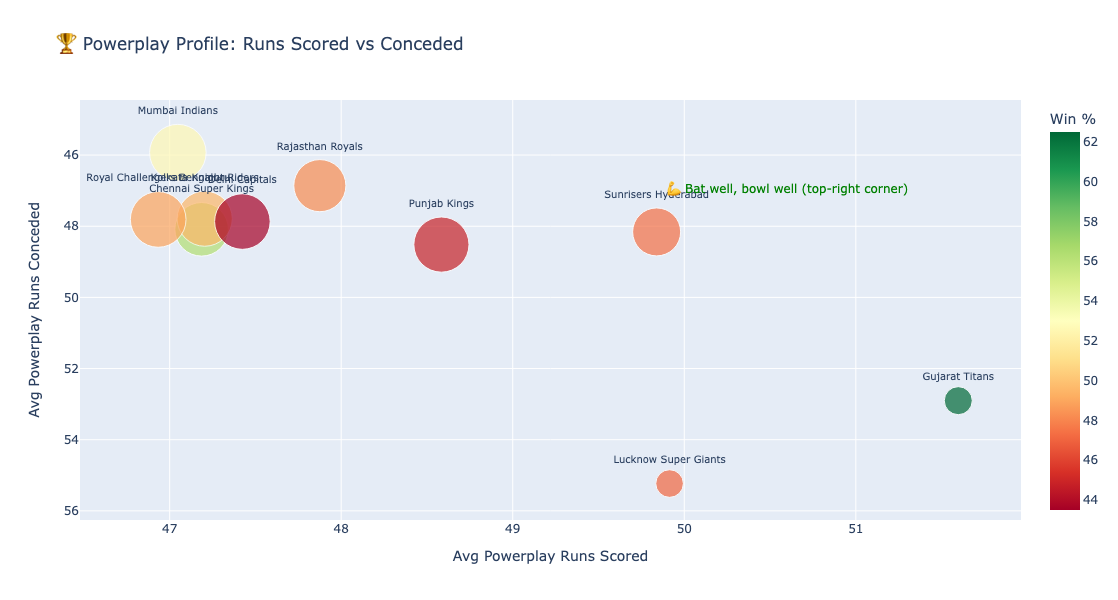

,team,avg_pp_scored,innings,wins,win_rate,avg_pp_conceded
2,Gujarat Titans,51.597222,72,45,62.5,52.902778
0,Chennai Super Kings,47.186312,263,148,56.3,48.087121
5,Mumbai Indians,47.047782,293,154,52.6,45.931741
3,Kolkata Knight Riders,47.204301,279,138,49.5,47.787770
8,Royal Challengers Bengaluru,46.933099,284,139,48.9,47.809187
7,Rajasthan Royals,47.875502,249,120,48.2,46.860000
9,Sunrisers Hyderabad,49.838863,211,100,47.4,48.160377
4,Lucknow Super Giants,49.914286,70,33,47.1,55.231884
6,Punjab Kings,48.584229,279,125,44.8,48.516129
1,Delhi Capitals,47.424028,283,123,43.5,47.868794


In [22]:
# Modern teams only - filter to teams playing in last 3 seasons
recent_seasons = sorted(matches['season'].dropna().unique())[-3:]
recent_teams = set()
for s in recent_seasons:
    recent_teams.update(matches[matches['season'] == s]['team1'].unique())
    recent_teams.update(matches[matches['season'] == s]['team2'].unique())

# For each team: avg powerplay runs scored AND avg powerplay runs CONCEDED, and overall win rate
team_pp_bat = (phase_wide[phase_wide['batting_team'].isin(recent_teams)]
    .groupby('batting_team')
    .agg(avg_pp_scored=('runs_powerplay', 'mean'),
         innings=('match_id', 'count'),
         wins=('batting_team_won', 'sum'))
    .reset_index()
    .rename(columns={'batting_team': 'team'}))
team_pp_bat['win_rate'] = (team_pp_bat['wins'] / team_pp_bat['innings'] * 100).round(1)

team_pp_bowl = (phase_wide[phase_wide['bowling_team'].isin(recent_teams)]
    .groupby('bowling_team')
    .agg(avg_pp_conceded=('runs_powerplay', 'mean'))
    .reset_index()
    .rename(columns={'bowling_team': 'team'}))

team_perf = team_pp_bat.merge(team_pp_bowl, on='team')
team_perf = team_perf[team_perf['innings'] >= 20].sort_values('win_rate', ascending=False)

fig = px.scatter(
    team_perf,
    x='avg_pp_scored', y='avg_pp_conceded',
    size='innings', color='win_rate',
    color_continuous_scale='RdYlGn',
    hover_name='team',
    text='team',
    size_max=40,
    title='🏆 Powerplay Profile: Runs Scored vs Conceded',
    labels={'avg_pp_scored': 'Avg Powerplay Runs Scored',
            'avg_pp_conceded': 'Avg Powerplay Runs Conceded',
            'win_rate': 'Win %'}
)
fig.update_traces(textposition='top center', textfont_size=10)
fig.update_yaxes(autorange='reversed')  # lower = better
fig.add_annotation(x=team_perf['avg_pp_scored'].max() - 1,
                   y=team_perf['avg_pp_conceded'].min() + 1,
                   text='💪 Bat well, bowl well (top-right corner)',
                   showarrow=False, font=dict(size=12, color='green'))
fig.update_layout(height=600)
fig.show()

team_perf

## 7. 🎯 Chasing Down: Win Probability by Required Run Rate

When chasing, a team's win chances depend heavily on the required run rate. Let's quantify it.

In [23]:
# We need the first-innings TOTAL to compute the target for innings 2
first_inn_totals = (
    deliveries[deliveries['innings'] == 1]
    .groupby('match_id')['total_runs'].sum()
    .reset_index()
    .rename(columns={'total_runs': 'first_innings_total'})
)
first_inn_totals['match_id'] = first_inn_totals['match_id'].astype(str)

# Innings-2 deliveries only - the chase
# Note: 'winner' is already in deliveries_features.csv (merged in get_ipl_data.py)
chase = deliveries[deliveries['innings'] == 2].copy()
chase['match_id'] = chase['match_id'].astype(str)
chase = chase.merge(first_inn_totals, on='match_id', how='left')

# Required run rate at each ball
chase['target']        = chase['first_innings_total'] + 1
chase['runs_needed']   = chase['target'] - chase['current_score']
chase['balls_left']    = chase['balls_remaining']
chase['req_run_rate']  = (chase['runs_needed'] / chase['balls_left'].replace(0, np.nan) * 6).round(2)
chase['chase_won']     = (chase['batting_team'] == chase['winner']).astype(int)

print('Chase rows:', len(chase))
chase[['match_id', 'over_num', 'current_score', 'target', 'runs_needed', 'balls_left', 'req_run_rate', 'chase_won']].head()

Chase rows: 140174


,match_id,over_num,current_score,target,runs_needed,balls_left,req_run_rate,chase_won
0,1082591,0,1,208,207,119,10.44,0
1,1082591,0,1,208,207,118,10.53,0
2,1082591,0,1,208,207,117,10.62,0
3,1082591,0,3,208,205,116,10.60,0
4,1082591,0,7,208,201,115,10.49,0


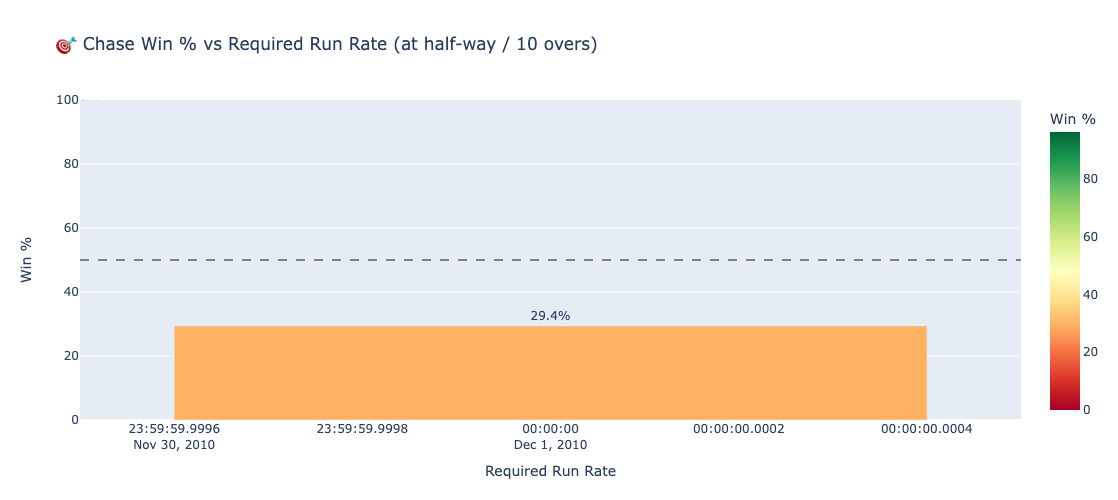

In [24]:
# Look at win % at the 10-over mark for different required run rates
mid_chase = chase[(chase['over_num'] == 9) & (chase['ball_in_over'] == 6)].copy()
# Some matches don't have exactly the 9.6 row; use closest to halfway
mid_chase = chase[chase['legal_balls_bowled'] == 60].copy()

mid_chase['rrr_bucket'] = pd.cut(
    mid_chase['req_run_rate'].clip(upper=20),
    bins=[0, 6, 8, 10, 12, 14, 30],
    labels=['<6', '6-8', '8-10', '10-12', '12-14', '14+']
)

rrr_win = (mid_chase.groupby('rrr_bucket', observed=True)
          .agg(matches=('match_id', 'count'),
               wins=('chase_won', 'sum'))
          .reset_index())
rrr_win['win_rate'] = (rrr_win['wins'] / rrr_win['matches'] * 100).round(1)

fig = px.bar(
    rrr_win,
    x='rrr_bucket', y='win_rate',
    text='win_rate',
    color='win_rate',
    color_continuous_scale='RdYlGn',
    hover_data={'matches': True, 'wins': True},
    title='🎯 Chase Win % vs Required Run Rate (at half-way / 10 overs)',
    labels={'rrr_bucket': 'Required Run Rate', 'win_rate': 'Win %'}
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(height=500, showlegend=False, yaxis_range=[0, 100])
fig.add_hline(y=50, line_dash='dash', line_color='grey')
fig.show()

## 8. 🏟️ Venue Insights

*Some grounds favour batting, some are bowler's friends. Which are which?*

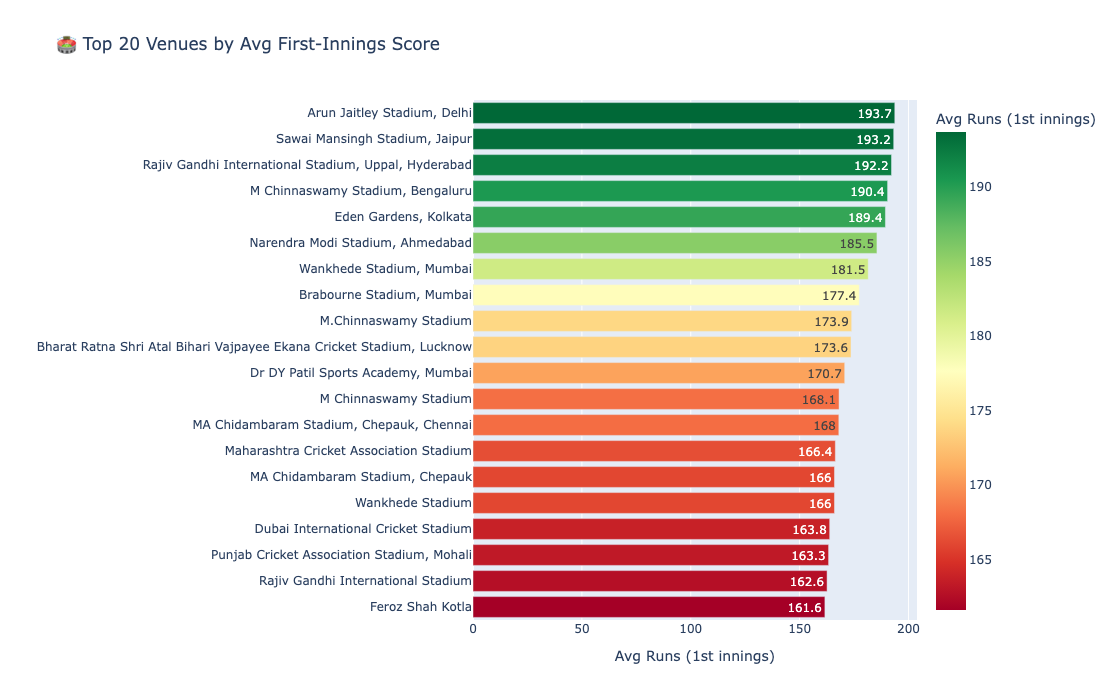

In [25]:
# Avg first-innings score by venue
venue_score = (
    deliveries[deliveries['innings'] == 1]
    .groupby(['match_id', 'venue'])['total_runs'].sum()
    .reset_index()
    .groupby('venue')
    .agg(avg_first_inn=('total_runs', 'mean'),
         matches=('match_id', 'count'))
    .reset_index()
)
venue_score = venue_score[venue_score['matches'] >= 15].sort_values('avg_first_inn', ascending=False)
venue_score['avg_first_inn'] = venue_score['avg_first_inn'].round(1)

fig = px.bar(
    venue_score.head(20),
    x='avg_first_inn', y='venue',
    orientation='h',
    text='avg_first_inn',
    color='avg_first_inn',
    color_continuous_scale='RdYlGn',
    hover_data={'matches': True},
    title='🏟️ Top 20 Venues by Avg First-Innings Score',
    labels={'avg_first_inn': 'Avg Runs (1st innings)', 'venue': ''}
)
fig.update_layout(height=700, yaxis={'categoryorder': 'total ascending'}, showlegend=False)
fig.show()

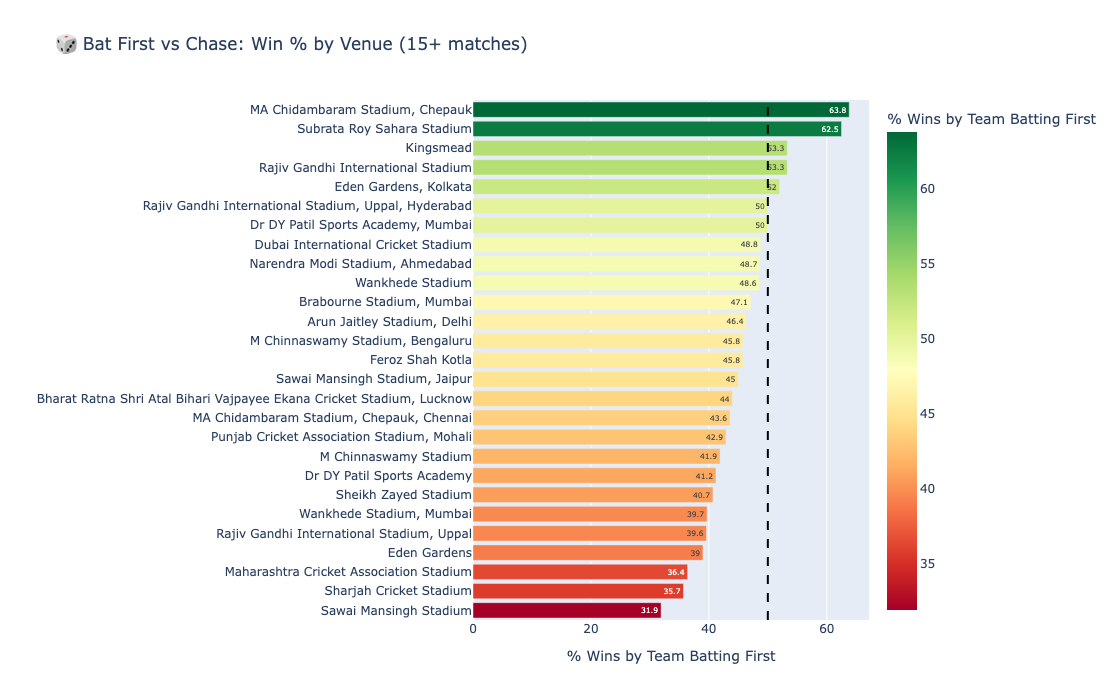

In [26]:
# For each venue, does batting first vs chasing win more?
matches_clean = matches.dropna(subset=['toss_decision', 'winner', 'team1', 'team2']).copy()

# The team that bats first is the toss winner if they chose 'bat', else the OTHER team
matches_clean['bat_first_team'] = np.where(
    matches_clean['toss_decision'] == 'bat',
    matches_clean['toss_winner'],
    np.where(matches_clean['toss_winner'] == matches_clean['team1'],
             matches_clean['team2'], matches_clean['team1'])
)
matches_clean['bat_first_won'] = (matches_clean['bat_first_team'] == matches_clean['winner']).astype(int)

venue_chase = (matches_clean.groupby('venue')
    .agg(matches=('match_id', 'count'),
         bat_first_wins=('bat_first_won', 'sum'))
    .reset_index())
venue_chase = venue_chase[venue_chase['matches'] >= 15]
venue_chase['bat_first_win_%'] = (venue_chase['bat_first_wins'] / venue_chase['matches'] * 100).round(1)
venue_chase = venue_chase.sort_values('bat_first_win_%', ascending=False)

fig = px.bar(
    venue_chase,
    x='bat_first_win_%', y='venue',
    orientation='h',
    text='bat_first_win_%',
    color='bat_first_win_%',
    color_continuous_scale='RdYlGn',
    hover_data={'matches': True},
    title='🎲 Bat First vs Chase: Win % by Venue (15+ matches)',
    labels={'bat_first_win_%': '% Wins by Team Batting First', 'venue': ''}
)
fig.add_vline(x=50, line_dash='dash', line_color='black')
fig.update_layout(height=700, yaxis={'categoryorder': 'total ascending'}, showlegend=False)
fig.show()

## 9. 🪙 Does the Toss Matter?

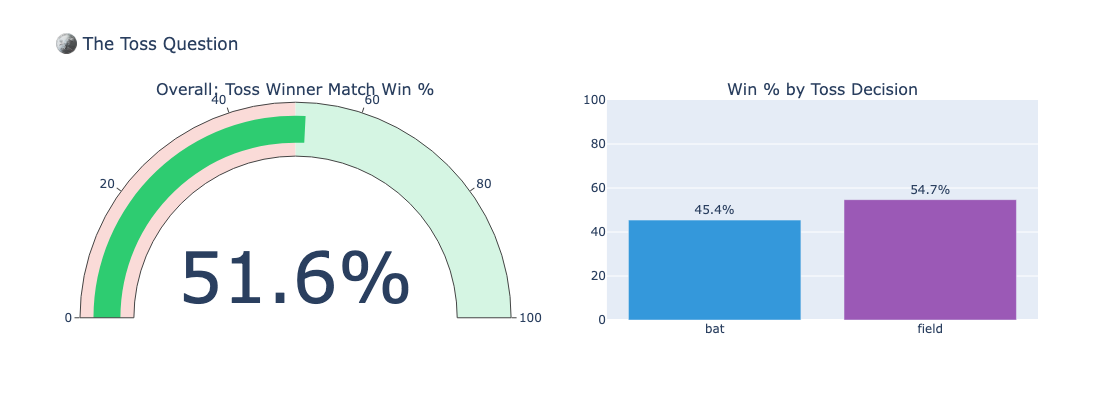

Toss winner wins match 51.6% of the time
  toss_decision  matches  toss_winner_wins  win_rate
0           bat      405               184      45.4
1         field      795               435      54.7


In [27]:
toss_data = matches_clean.copy()
toss_data['toss_winner_won_match'] = (toss_data['toss_winner'] == toss_data['winner']).astype(int)

# Overall
overall_toss = toss_data['toss_winner_won_match'].mean() * 100

# By decision
by_dec = (toss_data.groupby('toss_decision')
  .agg(matches=('match_id', 'count'),
       toss_winner_wins=('toss_winner_won_match', 'sum'))
  .reset_index())
by_dec['win_rate'] = (by_dec['toss_winner_wins'] / by_dec['matches'] * 100).round(1)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'indicator'}, {'type': 'bar'}]],
    subplot_titles=('Overall: Toss Winner Match Win %', 'Win % by Toss Decision')
)
fig.add_trace(go.Indicator(
    mode='gauge+number',
    value=overall_toss,
    domain={'x': [0, 1], 'y': [0, 1]},
    gauge={'axis': {'range': [0, 100]},
           'bar': {'color': '#2ecc71' if overall_toss > 50 else '#e74c3c'},
           'steps': [{'range': [0, 50], 'color': '#fadbd8'},
                     {'range': [50, 100], 'color': '#d5f5e3'}]},
    number={'suffix': '%'}
), row=1, col=1)
fig.add_trace(go.Bar(
    x=by_dec['toss_decision'], y=by_dec['win_rate'],
    text=by_dec['win_rate'].astype(str) + '%',
    textposition='outside',
    marker_color=['#3498db', '#9b59b6']
), row=1, col=2)
fig.update_layout(height=400, title='🪙 The Toss Question', showlegend=False)
fig.update_yaxes(range=[0, 100], row=1, col=2)
fig.show()

print(f'Toss winner wins match {overall_toss:.1f}% of the time')
print(by_dec)

## 10. 📈 The Live Win-Probability Curve

Build a win-probability curve for a chase: at any point during the chase, what's the historical win % for teams in similar situations?

/opt/anaconda3/lib/python3.11/site-packages/plotly/express/_core.py:1958: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



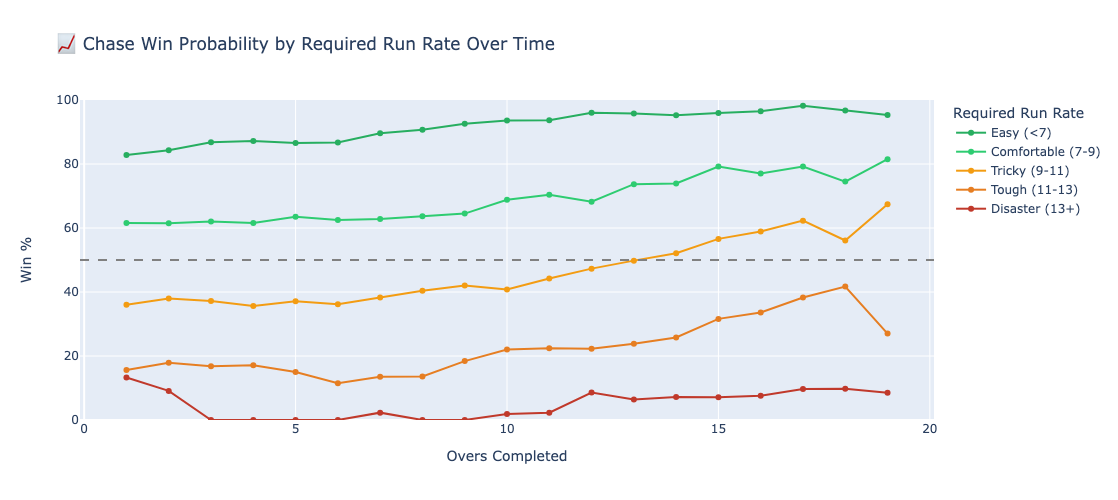

In [28]:
# For each over of the chase, compute win % grouped by required run rate bucket
chase_over = chase.copy()
chase_over['over_completed'] = (chase_over['legal_balls_bowled'] / 6).astype(int)

# Use ball at the END of each over only
end_of_over = chase_over[chase_over['legal_balls_bowled'] % 6 == 0].copy()
end_of_over = end_of_over[end_of_over['legal_balls_bowled'] > 0]

# Bucket RRR coarsely
end_of_over['rrr_band'] = pd.cut(
    end_of_over['req_run_rate'].clip(upper=25),
    bins=[-1, 7, 9, 11, 13, 30],
    labels=['Easy (<7)', 'Comfortable (7-9)', 'Tricky (9-11)', 'Tough (11-13)', 'Disaster (13+)']
)

curve = (end_of_over.groupby(['over_completed', 'rrr_band'], observed=True)
    .agg(matches=('match_id', 'count'),
         wins=('chase_won', 'sum'))
    .reset_index())
curve = curve[curve['matches'] >= 10]
curve['win_prob'] = (curve['wins'] / curve['matches'] * 100).round(1)

fig = px.line(
    curve,
    x='over_completed', y='win_prob',
    color='rrr_band',
    markers=True,
    title='📈 Chase Win Probability by Required Run Rate Over Time',
    labels={'over_completed': 'Overs Completed', 'win_prob': 'Win %',
            'rrr_band': 'Required Run Rate'},
    color_discrete_map={'Easy (<7)': '#27ae60', 'Comfortable (7-9)': '#2ecc71',
                       'Tricky (9-11)': '#f39c12', 'Tough (11-13)': '#e67e22',
                       'Disaster (13+)': '#c0392b'},
    hover_data={'matches': True}
)
fig.update_layout(height=500, yaxis_range=[0, 100])
fig.add_hline(y=50, line_dash='dash', line_color='grey')
fig.show()

## 11. ⚔️ Head-to-Head Matrix

Win % between current teams across all seasons.

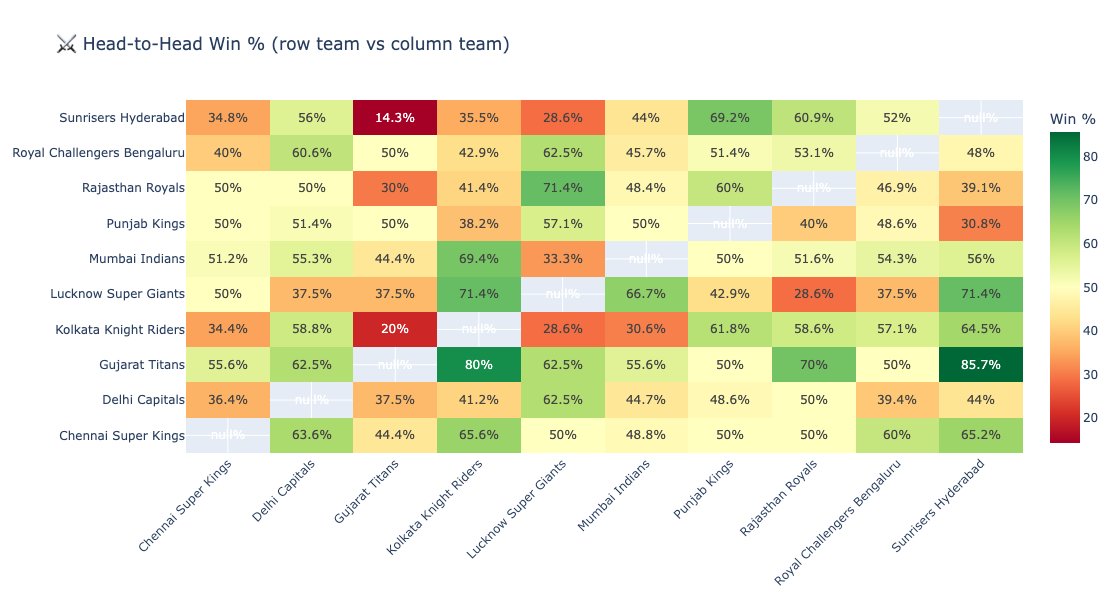

In [29]:
h2h = matches_clean[
    matches_clean['team1'].isin(recent_teams) &
    matches_clean['team2'].isin(recent_teams)
].copy()

teams_sorted = sorted(recent_teams)
matrix = pd.DataFrame(np.nan, index=teams_sorted, columns=teams_sorted)

for t1 in teams_sorted:
    for t2 in teams_sorted:
        if t1 == t2:
            continue
        games = h2h[((h2h['team1'] == t1) & (h2h['team2'] == t2)) |
                    ((h2h['team1'] == t2) & (h2h['team2'] == t1))]
        if len(games) > 0:
            t1_wins = (games['winner'] == t1).sum()
            matrix.loc[t1, t2] = round(t1_wins / len(games) * 100, 1)

fig = go.Figure(data=go.Heatmap(
    z=matrix.values,
    x=matrix.columns,
    y=matrix.index,
    colorscale='RdYlGn',
    zmid=50,
    text=matrix.values,
    texttemplate='%{text}%',
    hovertemplate='%{y} vs %{x}<br>Win Rate: %{z}%<extra></extra>',
    colorbar=dict(title='Win %')
))
fig.update_layout(
    title='⚔️ Head-to-Head Win % (row team vs column team)',
    height=600, width=900,
    xaxis={'tickangle': -45}
)
fig.show()

## 12. 🎬 Key Takeaways

Let's auto-generate a one-page narrative summary.

In [30]:
print('=' * 70)
print('🏏  IPL DATA: KEY INSIGHTS  🏏'.center(70))
print('=' * 70)
print()
print(f"📊  Dataset: {matches.shape[0]} matches  |  {deliveries.shape[0]:,} balls  |  "
      f"{int(deliveries['season'].nunique())} seasons")
print()

# Best powerplay bucket
best_pp = pp_win_rate.iloc[-1]
print(f"🔥  POWERPLAY: Teams scoring {best_pp['pp_runs_bucket']} in the powerplay win"
      f" {best_pp['win_rate_%']}% of the time ({int(best_pp['matches'])} innings)")

worst_pp = pp_win_rate.iloc[0]
print(f"💀  Conversely, scoring {worst_pp['pp_runs_bucket']} in the powerplay drops win % to"
      f" {worst_pp['win_rate_%']}%")
print()

# Wickets impact
no_wkt = pp_w_win[pp_w_win['pp_wkts_bucket'] == 0].iloc[0]
many_wkt = pp_w_win[pp_w_win['pp_wkts_bucket'] == pp_w_win['pp_wkts_bucket'].max()].iloc[0]
print(f"🎯  WICKETS: Losing 0 wickets in powerplay -> {no_wkt['win_rate_%']}% win rate")
print(f"             Losing {many_wkt['pp_wkts_label']} wickets in powerplay -> {many_wkt['win_rate_%']}% win rate")
print()

# Toss
print(f"🪙  TOSS: Winning the toss wins the match only {overall_toss:.1f}% of the time"
      f"  (basically a coin-flip)")
print()

# Best venue for batting
top_bat_venue = venue_score.iloc[0]
print(f"🏟️  BATTER'S PARADISE: {top_bat_venue['venue']}"
      f"  ({top_bat_venue['avg_first_inn']} avg 1st-inn score)")
print()

# Best team
best_team = team_perf.iloc[0]
print(f"🏆  TOP CURRENT TEAM: {best_team['team']}"
      f"  ({best_team['win_rate']}% win rate, {int(best_team['innings'])} innings)")
print()
print('=' * 70)
print("Next: open ipl_win_predictor.ipynb to build the ML model on these features")
print('=' * 70)

                     🏏  IPL DATA: KEY INSIGHTS  🏏                     

📊  Dataset: 1225 matches  |  291,328 balls  |  23 seasons

🔥  POWERPLAY: Teams scoring 70+ in the powerplay win 73.6% of the time (140 innings)
💀  Conversely, scoring <30 in the powerplay drops win % to 24.1%

🎯  WICKETS: Losing 0 wickets in powerplay -> 65.3% win rate
             Losing 4+ wickets in powerplay -> 17.9% win rate

🪙  TOSS: Winning the toss wins the match only 51.6% of the time  (basically a coin-flip)

🏟️  BATTER'S PARADISE: Arun Jaitley Stadium, Delhi  (193.7 avg 1st-inn score)

🏆  TOP CURRENT TEAM: Gujarat Titans  (62.5% win rate, 72 innings)

Next: open ipl_win_predictor.ipynb to build the ML model on these features
